Present assumptions:
- psuedobulked on CRE (removing MPRA barcode heterogenaity). 
- untransfected zeroes are detectable and have been removed
- Chimeric transcripts have been removed
- No systemic differences in cell number, tfection efficiency btwn reps (should change)
- There ARE systemic differences in dropout between replicates

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import itertools

1000


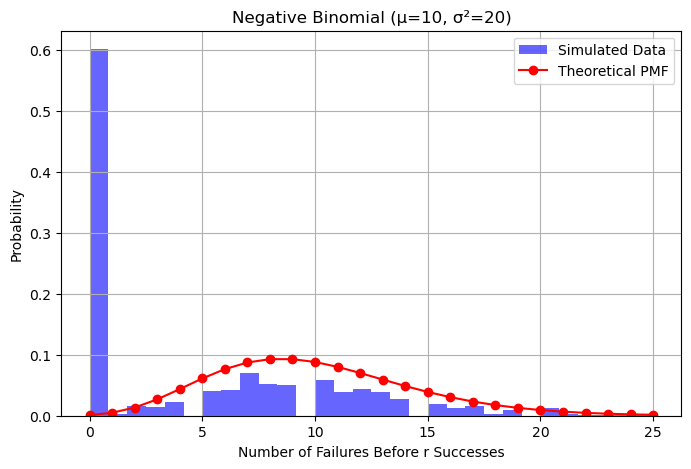

In [3]:

def plot_negative_binomial(samples, mu, sigma2):
    """
    Plot histogram and theoretical PMF of Negative Binomial distribution using mean and variance.
    """
    # Convert mean & variance to standard Negative Binomial parameters
    r = mu**2 / (sigma2 - mu)  # Number of successes
    p = mu / sigma2  # Probability of success

    plt.figure(figsize=(8, 5))
    plt.hist(samples, bins=30, density=True, alpha=0.6, color='b', label="Simulated Data")

    # Overlay theoretical Negative Binomial PMF
    x = np.arange(0, max(samples) + 1)
    pmf = stats.nbinom.pmf(x, r, p)
    plt.plot(x, pmf, 'ro-', label="Theoretical PMF")

    plt.xlabel("Number of Failures Before r Successes")
    plt.ylabel("Probability")
    plt.title(f"Negative Binomial (μ={mu}, σ²={sigma2})")
    plt.legend()
    plt.grid()
    plt.show()

def draw_nb(mu, sigma2, size):
    """
    Draw samples from a Negative Binomial distribution using mean and variance.

    Args:
        mu (float): Desired mean.
        sigma2 (float): Desired variance (must be > mu).
        size (int): Number of samples to draw.

    Returns:
        samples (array): Generated samples.
    """
    if sigma2 <= mu:
        raise ValueError("Variance must be greater than the mean (sigma² > μ)")

    # Convert mean & variance to standard Negative Binomial parameters
    r = mu**2 / (sigma2 - mu)  # Number of successes
    p = mu / sigma2  # Probability of success

    samples = np.random.negative_binomial(n=r, p=p, size=size)
    
    return samples

def draw_zinb(mu, sigma2, zin, size):
    """
        Args:
            mu (float): Desired mean.
            sigma2 (float): Desired variance (must be > mu).
            zin (float): 0-1 Desired fraction zero inflation. 
            size (int): Number of samples to draw.
    """

    zin_size=round(size*zin)
    non_zin_size=size-zin_size
    
    zerolist=pd.Series([0]*zin_size)
    draws=draw_nb(mu=mu,sigma2=sigma2,size=non_zin_size)

    return np.concatenate([zerolist,draws])

# Example usage:
mu = 10  # Mean
sigma2 = 20  # Variance
samples = draw_zinb(mu, sigma2,zin=0.5,size=1000)
print(len(samples))
plot_negative_binomial(samples, mu, sigma2)

In [4]:
data = {
    "CRE": ["nobody", "somebody", "everybody", "redgene", "neurogene", "nobody", "somebody", "everybody", "redgene", "neurogene"],
    "Cell-type": ["brain", "brain", "brain", "brain", "brain", "blood", "blood", "blood", "blood", "blood"],
    "mean": [1, 10, 114, 30, 99, 2, 12, 109, 112, 16]
}

# Creating the dataframe
cres = pd.DataFrame(data)

<Axes: xlabel='Cell-type', ylabel='mean'>

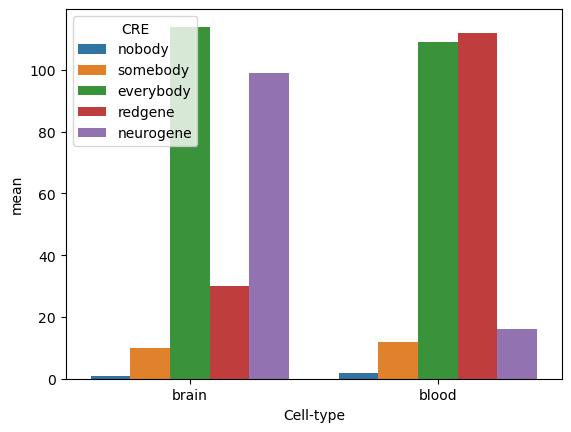

In [5]:
sns.barplot(cres,x="Cell-type",hue="CRE",y="mean")

In [6]:
#add variance column


np.random.seed(42) # so it's the same every time
cres["variance_constant"] = [0.3]*len(cres)
cres["sigmasquare"]=cres["mean"]+cres["variance_constant"]*cres["mean"]**2

In [7]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare
0,nobody,brain,1,0.3,1.3
1,somebody,brain,10,0.3,40.0
2,everybody,brain,114,0.3,4012.8
3,redgene,brain,30,0.3,300.0
4,neurogene,brain,99,0.3,3039.3
5,nobody,blood,2,0.3,3.2
6,somebody,blood,12,0.3,55.2
7,everybody,blood,109,0.3,3673.3
8,redgene,blood,112,0.3,3875.2
9,neurogene,blood,16,0.3,92.8


In [8]:
#add alterantive parametrization
cres["r"]=cres["mean"]**2/(cres["sigmasquare"]-cres["mean"])#also equal to 1/cres["variance_constant"]
cres["p"]=cres["mean"]/cres["sigmasquare"]

In [9]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p
0,nobody,brain,1,0.3,1.3,3.333333,0.769231
1,somebody,brain,10,0.3,40.0,3.333333,0.250000
2,everybody,brain,114,0.3,4012.8,3.333333,0.028409
3,redgene,brain,30,0.3,300.0,3.333333,0.100000
4,neurogene,brain,99,0.3,3039.3,3.333333,0.032573
5,nobody,blood,2,0.3,3.2,3.333333,0.625000
6,somebody,blood,12,0.3,55.2,3.333333,0.217391
7,everybody,blood,109,0.3,3673.3,3.333333,0.029674
8,redgene,blood,112,0.3,3875.2,3.333333,0.028902
9,neurogene,blood,16,0.3,92.8,3.333333,0.172414


In [10]:
# at this point, we have all of the information that would be replicate-indepndent. 
# Let's duplicate the table vertically to simulate 

total_reps=3
cres_duplicated = pd.concat([cres] * total_reps, ignore_index=True)
cres_duplicated['replicate_ID'] = [i + 1 for i in range(total_reps) for _ in range(len(cres))]

In [11]:
cres_duplicated

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID
0,nobody,brain,1,0.3,1.3,3.333333,0.769231,1
1,somebody,brain,10,0.3,40.0,3.333333,0.250000,1
2,everybody,brain,114,0.3,4012.8,3.333333,0.028409,1
3,redgene,brain,30,0.3,300.0,3.333333,0.100000,1
4,neurogene,brain,99,0.3,3039.3,3.333333,0.032573,1
5,nobody,blood,2,0.3,3.2,3.333333,0.625000,1
6,somebody,blood,12,0.3,55.2,3.333333,0.217391,1
7,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1
8,redgene,blood,112,0.3,3875.2,3.333333,0.028902,1
9,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1


In [12]:
cres=cres_duplicated

In [13]:
#let's pretend..
#In each replicate there were 1000 blood cells and 900 brain cells, and transfection efficiency for each CRE ~ N(0.5,0.01)
#to be more sophisticated, we could introduce systemic differences in cell number, tfection efficiency btwn reps...
np.random.seed(413) # so it's the same every time
cres["transfection_efficiency"]=np.random.normal(loc=0.5, scale=0.01, size=len(cres))
cres["cells"]=cres["Cell-type"].map({"brain":900,"blood":1000})*cres["transfection_efficiency"]
cres["cells"]=cres["cells"].round().astype(int)

In [14]:

#add zero inflation column
#this represents dropout due to RNA degredation, etc
#RNA dropout for each CRE ~ N(x,0.01) for rep 1 x=0.8, rep 2 x=0.5, rep3 x=0.9

np.random.seed(413)

zeroinfl=[]
for infl in [0.8,0.5,0.9]:
    zeroinfl.append(np.random.normal(loc=infl, scale=0.01, size=int(len(cres)/3)))

cres["zeroinfl"]=np.concatenate(zeroinfl)


In [15]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID,transfection_efficiency,cells,zeroinfl
0,nobody,brain,1,0.3,1.3,3.333333,0.769231,1,0.488506,440,0.788506
1,somebody,brain,10,0.3,40.0,3.333333,0.250000,1,0.515676,464,0.815676
2,everybody,brain,114,0.3,4012.8,3.333333,0.028409,1,0.501541,451,0.801541
3,redgene,brain,30,0.3,300.0,3.333333,0.100000,1,0.492430,443,0.792430
4,neurogene,brain,99,0.3,3039.3,3.333333,0.032573,1,0.516259,465,0.816259
5,nobody,blood,2,0.3,3.2,3.333333,0.625000,1,0.499099,499,0.799099
6,somebody,blood,12,0.3,55.2,3.333333,0.217391,1,0.504306,504,0.804306
7,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1,0.501417,501,0.801417
8,redgene,blood,112,0.3,3875.2,3.333333,0.028902,1,0.495357,495,0.795357
9,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1,0.498538,499,0.798538


In [16]:
np.random.seed(612)
def wrapper(row):
    #print(type(row["cells"]))
    return draw_zinb(mu=row["mean"], sigma2=row["sigmasquare"], zin=row["zeroinfl"], size=row["cells"])

cres["draws"]=cres.apply(wrapper,axis=1)


In [17]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID,transfection_efficiency,cells,zeroinfl,draws
0,nobody,brain,1,0.3,1.3,3.333333,0.769231,1,0.488506,440,0.788506,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,somebody,brain,10,0.3,40.0,3.333333,0.250000,1,0.515676,464,0.815676,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,everybody,brain,114,0.3,4012.8,3.333333,0.028409,1,0.501541,451,0.801541,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,redgene,brain,30,0.3,300.0,3.333333,0.100000,1,0.492430,443,0.792430,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,neurogene,brain,99,0.3,3039.3,3.333333,0.032573,1,0.516259,465,0.816259,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,nobody,blood,2,0.3,3.2,3.333333,0.625000,1,0.499099,499,0.799099,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,somebody,blood,12,0.3,55.2,3.333333,0.217391,1,0.504306,504,0.804306,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1,0.501417,501,0.801417,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,redgene,blood,112,0.3,3875.2,3.333333,0.028902,1,0.495357,495,0.795357,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1,0.498538,499,0.798538,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [18]:
#shuffle the draws to avoid having all the zeroes lumped together at the front
np.random.seed(413)
cres['draws'] = cres['draws'].apply(lambda x: list(np.random.permutation(x)))


In [19]:
#Subsetting to those data that will be accessible after the assay is performed.
cres_reduced=cres[["CRE","Cell-type","replicate_ID","draws","cells"]]

In [20]:
cres_reduced

,CRE,Cell-type,replicate_ID,draws,cells
0,nobody,brain,1,"[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, ...",440
1,somebody,brain,1,"[0, 0, 0, 0, 0, 0, 19, 0, 0, 12, 6, 0, 9, 0, 0...",464
2,everybody,brain,1,"[0, 0, 0, 0, 0, 0, 0, 30, 0, 20, 0, 0, 0, 0, 0...",451
3,redgene,brain,1,"[3, 0, 0, 24, 32, 0, 49, 0, 0, 0, 0, 0, 0, 0, ...",443
4,neurogene,brain,1,"[0, 0, 39, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",465
5,nobody,blood,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, ...",499
6,somebody,blood,1,"[0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 6, 0, 0, 0, ...",504
7,everybody,blood,1,"[0, 0, 0, 0, 0, 70, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",501
8,redgene,blood,1,"[0, 0, 164, 0, 178, 0, 0, 0, 0, 0, 0, 43, 0, 0...",495
9,neurogene,blood,1,"[0, 0, 0, 0, 0, 27, 0, 0, 7, 0, 0, 0, 0, 0, 0,...",499


Now let's add cell_bc. Each combination of replicate, cell_id gets its own set of cell barcodes.

In [21]:
#for each combination of col values that represents one set of cells, we wish to get the max number of cells
cell_sets=cres_reduced.groupby(["Cell-type","replicate_ID"])['cells'].agg('max')
cell_sets

Cell-type  replicate_ID
blood      1               504
           2               522
           3               523
brain      1               465
           2               465
           3               457
Name: cells, dtype: int64

In [22]:
def generate_barcodes(length, count):
    if 4**length < count:
        raise ValueError("Not enough unique barcodes of given length.")

    digit_to_base = ['A', 'C', 'G', 'T']
    barcodes = []

    for i in range(count):
        barcode = []
        n = i
        for _ in range(length):
            barcode.append(digit_to_base[n % 4])
            n //= 4
        # If length not fully filled, pad with 'A's
        while len(barcode) < length:
            barcode.append('A')
        barcodes.append(''.join(reversed(barcode)))

    return barcodes

barcodes=generate_barcodes(16,cell_sets.sum())

In [23]:
def assign_barcodes(df, barcodes):
    assigned = []
    i = 0
    for num in df['cells']:
        assigned.append(barcodes[i : i + num])
        i += num
    df = df.copy()
    df['assigned_barcodes'] = assigned
    return df

assignation=assign_barcodes(pd.DataFrame(cell_sets).reset_index(),barcodes)

In [24]:
assignation

,Cell-type,replicate_ID,cells,assigned_barcodes
0,blood,1,504,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
1,blood,2,522,"[AAAAAAAAAAACTTGA, AAAAAAAAAAACTTGC, AAAAAAAAA..."
2,blood,3,523,"[AAAAAAAAAACAAAAG, AAAAAAAAAACAAAAT, AAAAAAAAA..."
3,brain,1,465,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
4,brain,2,465,"[AAAAAAAAAACTTCTG, AAAAAAAAAACTTCTT, AAAAAAAAA..."
5,brain,3,457,"[AAAAAAAAAAGCGGTT, AAAAAAAAAAGCGTAA, AAAAAAAAA..."


In [25]:
assert all(assignation["assigned_barcodes"].apply(len)==assignation["cells"])

Nice! ok, let's add to cres_reduced

In [26]:
assignation=pd.merge(cres_reduced,assignation,how="left",on=["Cell-type","replicate_ID"])#.explode(['draws','assigned_barcodes']).reset_index(drop=True)
assignation

,CRE,Cell-type,replicate_ID,draws,cells_x,cells_y,assigned_barcodes
0,nobody,brain,1,"[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, ...",440,465,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
1,somebody,brain,1,"[0, 0, 0, 0, 0, 0, 19, 0, 0, 12, 6, 0, 9, 0, 0...",464,465,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
2,everybody,brain,1,"[0, 0, 0, 0, 0, 0, 0, 30, 0, 20, 0, 0, 0, 0, 0...",451,465,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
3,redgene,brain,1,"[3, 0, 0, 24, 32, 0, 49, 0, 0, 0, 0, 0, 0, 0, ...",443,465,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
4,neurogene,brain,1,"[0, 0, 39, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",465,465,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
5,nobody,blood,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, ...",499,504,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
6,somebody,blood,1,"[0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 6, 0, 0, 0, ...",504,504,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
7,everybody,blood,1,"[0, 0, 0, 0, 0, 70, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",501,504,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
8,redgene,blood,1,"[0, 0, 164, 0, 178, 0, 0, 0, 0, 0, 0, 43, 0, 0...",495,504,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
9,neurogene,blood,1,"[0, 0, 0, 0, 0, 27, 0, 0, 7, 0, 0, 0, 0, 0, 0,...",499,504,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."


In [27]:
assignation=assignation.drop("cells_y",axis=1).rename({'cells_x':'cells'},axis=1)

In [28]:
def trunk(row):
    return row["assigned_barcodes"][0:row["cells"]]
assignation["assigned_barcodes"]=assignation.apply(trunk,axis=1)

In [29]:
assignation

,CRE,Cell-type,replicate_ID,draws,cells,assigned_barcodes
0,nobody,brain,1,"[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, ...",440,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
1,somebody,brain,1,"[0, 0, 0, 0, 0, 0, 19, 0, 0, 12, 6, 0, 9, 0, 0...",464,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
2,everybody,brain,1,"[0, 0, 0, 0, 0, 0, 0, 30, 0, 20, 0, 0, 0, 0, 0...",451,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
3,redgene,brain,1,"[3, 0, 0, 24, 32, 0, 49, 0, 0, 0, 0, 0, 0, 0, ...",443,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
4,neurogene,brain,1,"[0, 0, 39, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",465,"[AAAAAAAAAACGAATC, AAAAAAAAAACGAATG, AAAAAAAAA..."
5,nobody,blood,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, ...",499,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
6,somebody,blood,1,"[0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 6, 0, 0, 0, ...",504,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
7,everybody,blood,1,"[0, 0, 0, 0, 0, 70, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",501,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
8,redgene,blood,1,"[0, 0, 164, 0, 178, 0, 0, 0, 0, 0, 0, 43, 0, 0...",495,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
9,neurogene,blood,1,"[0, 0, 0, 0, 0, 27, 0, 0, 7, 0, 0, 0, 0, 0, 0,...",499,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."


In [30]:
cres_reduced=assignation.explode(['draws', 'assigned_barcodes']).reset_index(drop=True)

In [31]:
cres_reduced

,CRE,Cell-type,replicate_ID,draws,cells,assigned_barcodes
0,nobody,brain,1,2,440,AAAAAAAAAACGAATC
1,nobody,brain,1,0,440,AAAAAAAAAACGAATG
2,nobody,brain,1,0,440,AAAAAAAAAACGAATT
3,nobody,brain,1,0,440,AAAAAAAAAACGACAA
4,nobody,brain,1,0,440,AAAAAAAAAACGACAC
...,...,...,...,...,...,...
14307,neurogene,blood,3,0,490,AAAAAAAAAACCTGCT
14308,neurogene,blood,3,0,490,AAAAAAAAAACCTGGA
14309,neurogene,blood,3,0,490,AAAAAAAAAACCTGGC
14310,neurogene,blood,3,0,490,AAAAAAAAAACCTGGG


In [32]:
def check_barcode_uniqueness(df, group_by_col):
    from itertools import combinations

    grouped = df.groupby(group_by_col)['assigned_barcodes'].agg(set)

    for (group1, barcodes1), (group2, barcodes2) in combinations(grouped.items(), 2):
        overlap = barcodes1 & barcodes2
        if overlap:
            print(f"[!] Overlapping barcodes between {group1} and {group2}:")
            print(f"   {len(overlap)} overlapping barcodes (e.g. {list(overlap)[:5]})")
            return False

    print(f"[+] All {group_by_col} groups have unique barcode sets.")
    return True

assert check_barcode_uniqueness(cres_reduced,"Cell-type")
assert check_barcode_uniqueness(cres_reduced,"replicate_ID")

[+] All Cell-type groups have unique barcode sets.
[+] All replicate_ID groups have unique barcode sets.


In [33]:
#one we expect to have overlap:
assert not check_barcode_uniqueness(cres_reduced,"CRE")

[!] Overlapping barcodes between everybody and neurogene:
   2844 overlapping barcodes (e.g. ['AAAAAAAAAACGATAT', 'AAAAAAAAAACGGTCC', 'AAAAAAAAAACGGTTT', 'AAAAAAAAAAATCGCT', 'AAAAAAAAAAACGCCA'])


In [34]:
cres_reduced=cres_reduced.rename({'draws':'umis_mpra_bc','replicate_ID':'rep_id','assigned_barcodes':'cell_bc','CRE':'cre_id','Cell-type':'cell_type'},axis=1)[["cell_bc","rep_id","cre_id","cell_type","umis_mpra_bc"]]

In [35]:
cres_reduced

,cell_bc,rep_id,cre_id,cell_type,umis_mpra_bc
0,AAAAAAAAAACGAATC,1,nobody,brain,2
1,AAAAAAAAAACGAATG,1,nobody,brain,0
2,AAAAAAAAAACGAATT,1,nobody,brain,0
3,AAAAAAAAAACGACAA,1,nobody,brain,0
4,AAAAAAAAAACGACAC,1,nobody,brain,0
...,...,...,...,...,...
14307,AAAAAAAAAACCTGCT,3,neurogene,blood,0
14308,AAAAAAAAAACCTGGA,3,neurogene,blood,0
14309,AAAAAAAAAACCTGGC,3,neurogene,blood,0
14310,AAAAAAAAAACCTGGG,3,neurogene,blood,0


In [36]:
agg=pd.DataFrame(cres_reduced.groupby(["cre_id","cell_type"])['umis_mpra_bc'].agg('sum')).reset_index()

In [37]:
agg

,cre_id,cell_type,umis_mpra_bc
0,everybody,blood,44543
1,everybody,brain,40962
2,neurogene,blood,6275
3,neurogene,brain,34733
4,nobody,blood,823
5,nobody,brain,360
6,redgene,blood,44821
7,redgene,brain,10533
8,somebody,blood,4554
9,somebody,brain,3640


<Axes: xlabel='cell_type', ylabel='umis_mpra_bc'>

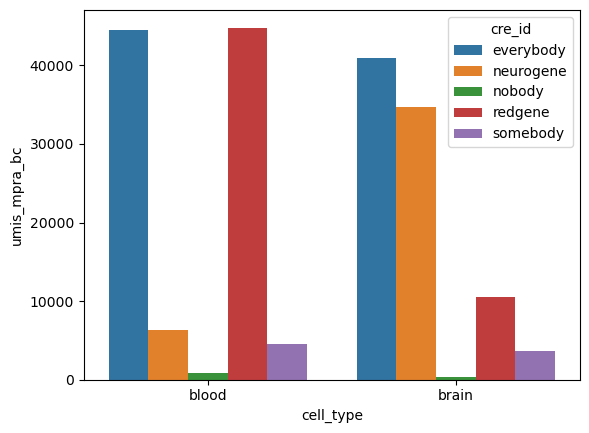

In [38]:
sns.barplot(agg,x="cell_type",hue="cre_id",y="umis_mpra_bc")

In [39]:
cres_reduced.to_csv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres_shufflerepair.tsv",sep="\t")